# Datos faltantes con Penguins

Se trabajarà dataset **Penguins** para ejemplificar cómo detectar, resumir e imputar valores faltantes.

## Objetivos

- inspeccionar los valores faltantes
- revisar los patrones de ausencia de datos
- ajustar un modelo de regresión con casos completos
- realizar un análisis tipo imputación múltiple
- comparar imputación por mediana, por árboles y por vecinos más cercanos


## Importaciones

In [2]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm



## Cargar e inspeccionar el dataset


In [3]:
penguins = pd.read_csv('../data/penguins.csv')

print('Dataset original: ', penguins.shape)
penguins.head()

Dataset original:  (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
def porcentaje_datos_faltantes(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula la cantidad y el porcentaje de datos faltantes por columna.
    Devuelve solo las columnas que tienen al menos un valor faltante.
    """
    cantidad_faltantes = dataframe.isna().sum()
    porcentaje_faltantes = ((cantidad_faltantes / len(dataframe)) * 100).round(2)

    resumen_faltantes = pd.DataFrame({
        'cantidad_faltantes': cantidad_faltantes,
        'porcentaje_faltantes': porcentaje_faltantes
    })

    resumen_faltantes = resumen_faltantes[resumen_faltantes['cantidad_faltantes'] > 0]
    resumen_faltantes = resumen_faltantes.sort_values(
        by='porcentaje_faltantes',
        ascending=False
    )

    return resumen_faltantes


In [5]:

tabla_faltantes = porcentaje_datos_faltantes(penguins)
tabla_faltantes


,cantidad_faltantes,porcentaje_faltantes
sex,11,3.20
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58



## Tabla con descripciòn de variables

| Columna             | Tipo de variable  | Descripción |
| ------------------- | ----------------- | ----------- |
| `species`           | Categórica        | Especie del pingüino. |
| `island`            | Categórica        | Isla donde fue observado o medido. |
| `bill_length_mm`    | Numérica continua | Longitud del pico en milímetros. |
| `bill_depth_mm`     | Numérica continua | Profundidad del pico en milímetros. |
| `flipper_length_mm` | Numérica continua | Longitud de la aleta en milímetros. |
| `body_mass_g`       | Numérica continua | Masa corporal en gramos. |
| `sex`               | Categórica        | Sexo del pingüino. |
| `year`              | Numérica discreta | Año del registro. |



## Valores faltantes en variables numèricas


In [6]:

columnas_numericas = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

penguins_num = penguins[columnas_numericas].copy()
print('Dimensiones de variables numèricas', penguins_num.shape)
penguins_num.head()

Dimensiones de variables numèricas (344, 4)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0


In [7]:
resumen_faltantes_numericas = pd.DataFrame({
    'conteo_faltantes': penguins_num.isna().sum(),
    'porcentaje_faltantes': (penguins_num.isna().mean() * 100).round(2)
})
resumen_faltantes_numericas


,conteo_faltantes,porcentaje_faltantes
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58


In [8]:

def graficar_distribuciones_variables(
    df: pd.DataFrame,
    columnas: list[str],
    nombres_es: dict | None = None,
    ncols: int = 4,
    bins: int = 20,
    kde: bool = True,
    titulo: str = 'Distribución de las variables'
) -> None:
    n_variables = len(columnas)
    nrows = math.ceil(n_variables / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 4 * nrows)
    )

    axes = np.atleast_1d(axes).flatten()

    for i, columna in enumerate(columnas):
        ax = axes[i]
        nombre_mostrar = nombres_es.get(columna, columna) if nombres_es else columna

        if pd.api.types.is_numeric_dtype(df[columna]):
            sns.histplot(
                df[columna].dropna(),
                bins=bins,
                kde=kde,
                ax=ax,
                color="#0072B2"
            )
            ax.set_ylabel('Frecuencia')
        else:
            serie_grafica = df[columna].astype(object).fillna('Faltante').astype(str)
            conteos = serie_grafica.value_counts()

            ax.bar(
                conteos.index,
                conteos.values,
                color="#0072B2",
                edgecolor="black"
            )
            ax.set_ylabel('Conteo')
            ax.tick_params(axis='x', rotation=45)

        ax.set_title(nombre_mostrar)
        ax.set_xlabel(nombre_mostrar)

    for j in range(len(columnas), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

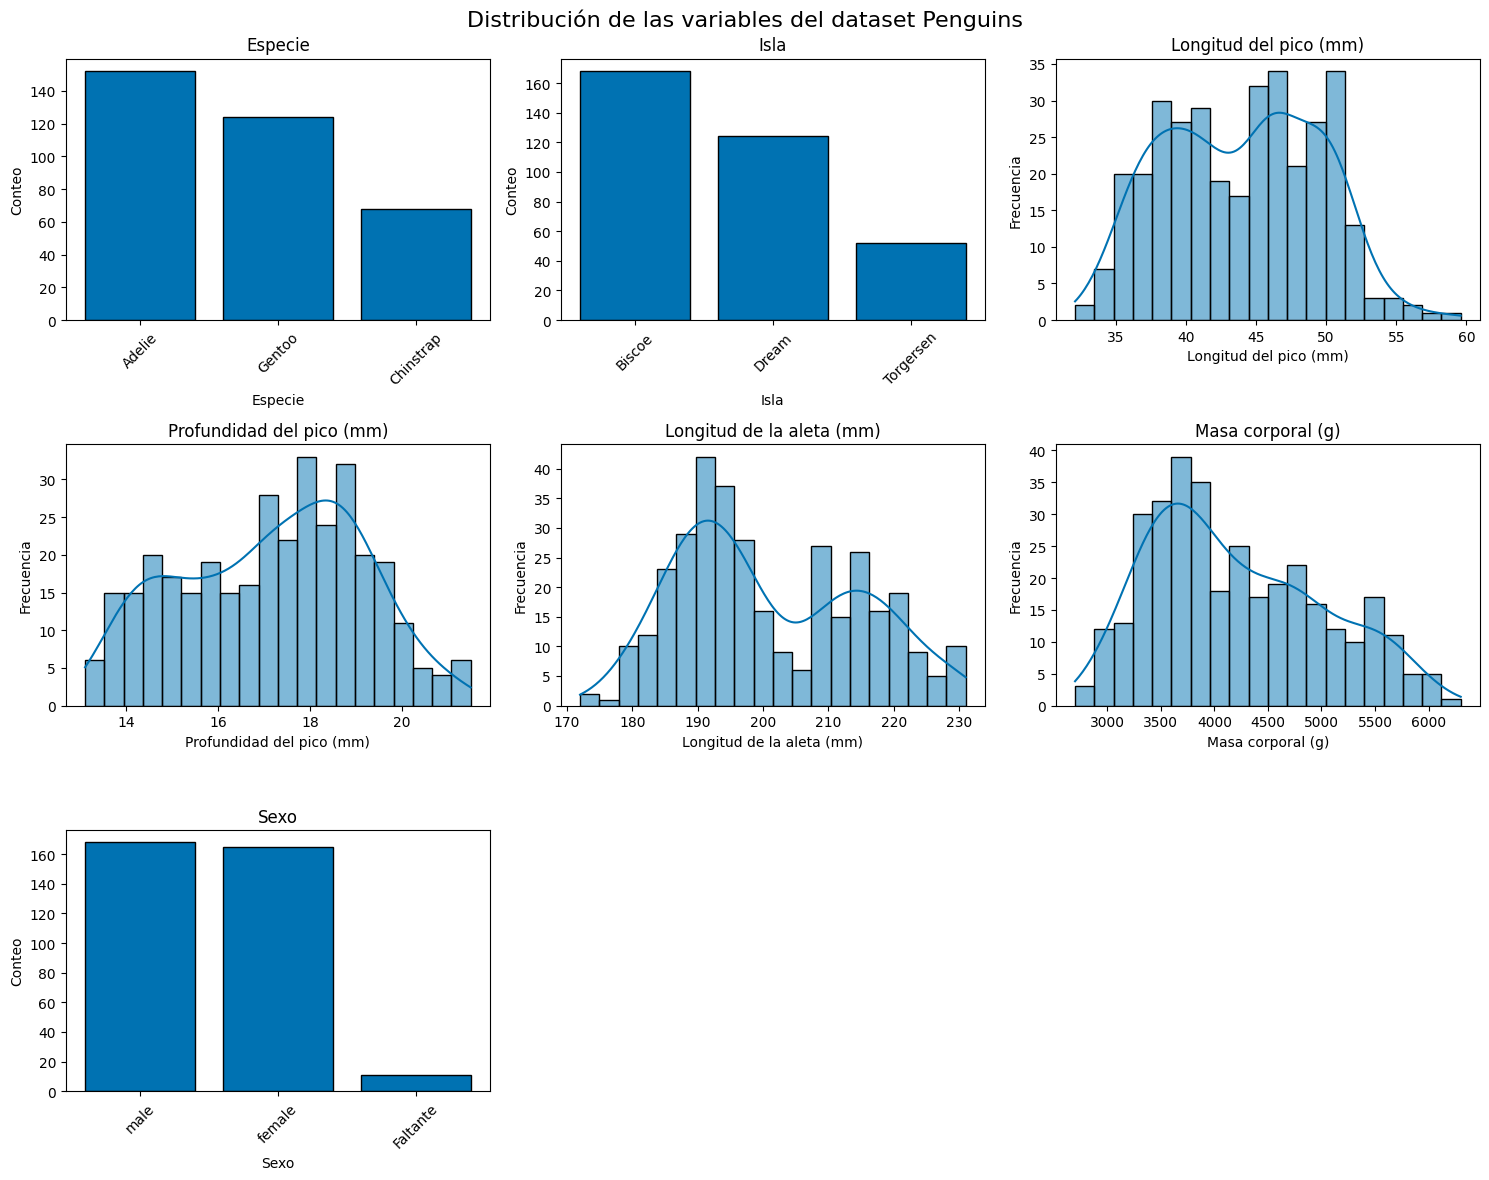

In [9]:

columnas_graficas = [
    'species',
    'island',
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g',
    'sex'
]

nombres_es = {
    'species': 'Especie',
    'island': 'Isla',
    'bill_length_mm': 'Longitud del pico (mm)',
    'bill_depth_mm': 'Profundidad del pico (mm)',
    'flipper_length_mm': 'Longitud de la aleta (mm)',
    'body_mass_g': 'Masa corporal (g)',
    'sex': 'Sexo'
}

graficar_distribuciones_variables(
    df=penguins,
    columnas=columnas_graficas,
    nombres_es=nombres_es,
    ncols=3,
    bins=20,
    kde=True,
    titulo='Distribución de las variables del dataset Penguins'
)


¿Existen sesgos en la distribuciòn de alguna de las variables?


In [10]:
def graficar_boxplots(
    df: pd.DataFrame,
    columnas: list[str],
    nombres_es: dict | None = None,
    ncols: int = 4,
    titulo: str = 'Diagramas de caja'
) -> None:
    columnas_validas = [columna for columna in columnas if columna in df.columns]
    columnas_numericas = [
        columna for columna in columnas_validas
        if pd.api.types.is_numeric_dtype(df[columna])
    ]

    n_variables = len(columnas_numericas)
    nrows = math.ceil(n_variables / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 4 * nrows)
    )

    axes = np.atleast_1d(axes).flatten()

    for i, columna in enumerate(columnas_numericas):
        ax = axes[i]
        nombre_mostrar = nombres_es.get(columna, columna) if nombres_es else columna
        ax.boxplot(df[columna].dropna(), vert=True)
        ax.set_title(nombre_mostrar)
        ax.set_ylabel(nombre_mostrar)
        ax.set_xlabel('')

    for j in range(len(columnas_numericas), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()


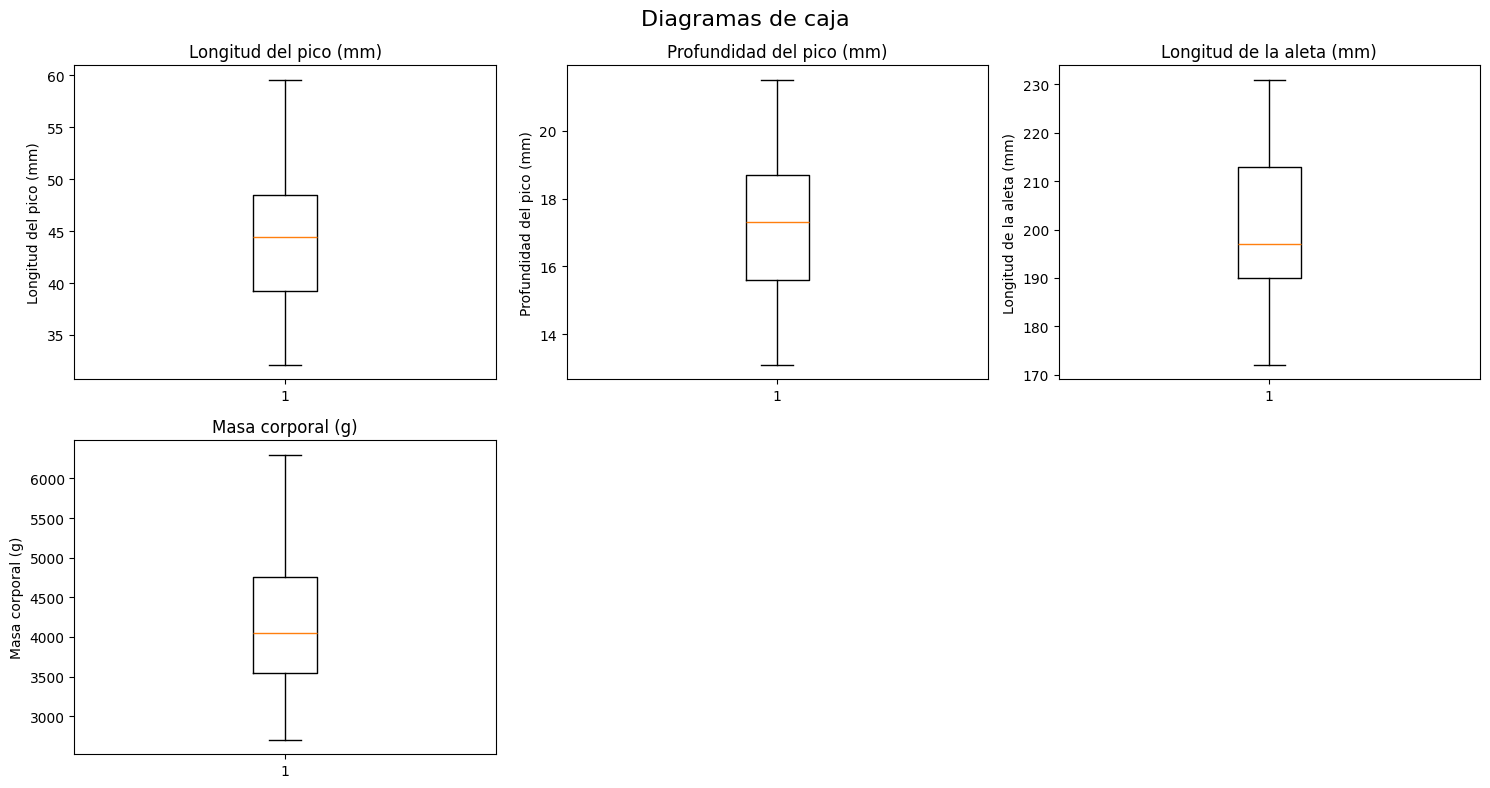

In [11]:
graficar_boxplots(
    df=penguins,
    columnas=columnas_graficas,
    nombres_es=nombres_es,
    ncols=3,
    titulo='Diagramas de caja'
)



## Datos faltantes

Un valor de `1` significa que la variable está ausente en esa fila y `0` significa que está observada.


In [12]:

tabla_patrones = (
    penguins_num
    .isna()
    .astype(int)
    .value_counts()
    .rename('conteo')
    .reset_index()
    .sort_values('conteo', ascending=False)
    .reset_index(drop=True)
)

tabla_patrones.head(20)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,conteo
0,0,0,0,0,342
1,1,1,1,1,2


In [13]:
rows_with_missing_full = penguins.loc[penguins_num.isna().any(axis=1)]
rows_with_missing_full

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [14]:
numeric_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

corrrelacion_matriz = penguins[numeric_columns].corr()

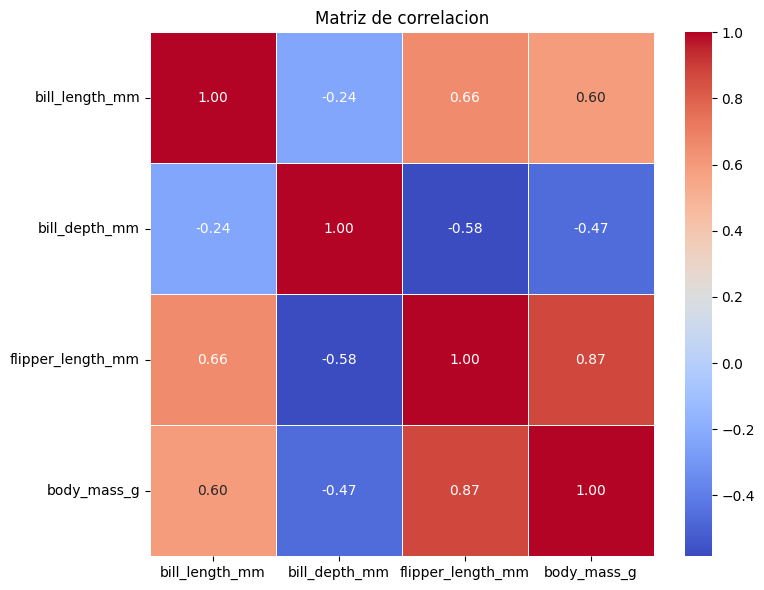

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corrrelacion_matriz,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()

La matriz de correlación muestra que flipper_length_mm es la variable más fuertemente asociada con body_mass_g (r = 0.87). Por ello, se considera una buena candidata como variable predictora en un modelo de regresión lineal simple para imputar o estimar la masa corporal.

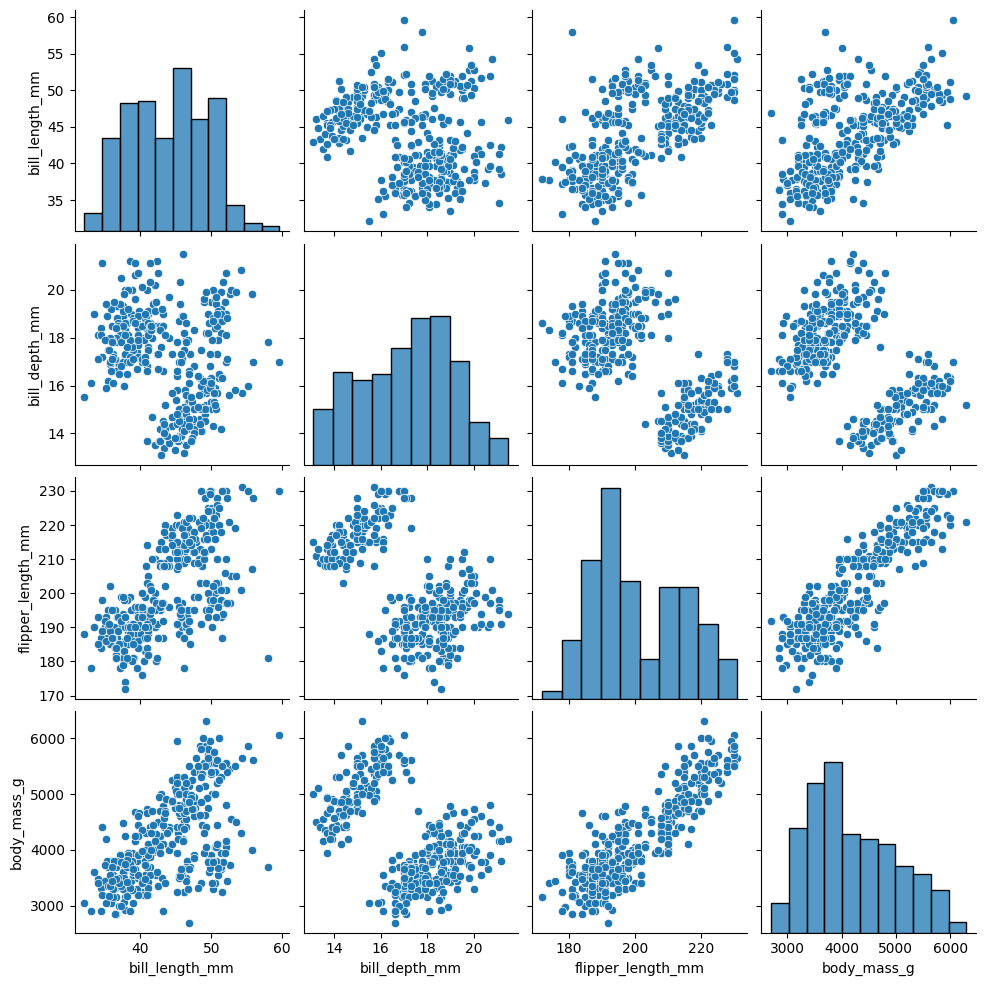

In [16]:
sns.pairplot(penguins[numeric_columns].dropna())
plt.show()

¿qué variables parecen tener relación?

¿la relación es positiva o negativa?

¿la relación se ve lineal?

¿hay grupos o patrones?

¿hay valores atípicos?

## Funciones para aplicar cada mètodo y tratar valors faltantes

In [17]:

def ajustar_modelo_lineal(
    datos: pd.DataFrame,
    variable_objetivo: str = 'body_mass_g',
    variable_predictora: str = 'flipper_length_mm'
) -> dict:
    """
    Ajusta una regresión lineal simple
    """
    datos_modelo = datos[[variable_predictora, variable_objetivo]].dropna().copy()

    X = sm.add_constant(datos_modelo[[variable_predictora]])
    y = datos_modelo[variable_objetivo]

    modelo = sm.OLS(y, X).fit()
    predicciones = modelo.predict(X)

    rmse = np.sqrt(mean_squared_error(y, predicciones))
    r2 = r2_score(y, predicciones)

    return {
        'modelo': modelo,
        'n_observaciones': len(datos_modelo),
        'intercepto': modelo.params['const'],
        'error_estandar_intercepto': modelo.bse['const'],
        'pendiente': modelo.params[variable_predictora],
        'error_estandar_pendiente': modelo.bse[variable_predictora],
        'r2': r2,
        'rmse': rmse
    }


def resumir_modelo(resultado: dict, metodo: str) -> pd.DataFrame:
    """
    Convierte el resultado del modelo en una tabla de una fila.
    """
    return pd.DataFrame([
        {
            'metodo': metodo,
            'n_observaciones': resultado['n_observaciones'],
            'intercepto': resultado['intercepto'],
            'pendiente': resultado['pendiente'],
            'r2': resultado['r2'],
            'rmse': resultado['rmse']
        }
    ])


def reglas_de_rubin(estimaciones, errores_estandar):
    """
    Combina estimaciones obtenidas a partir de múltiples imputaciones.
    """
    estimaciones = np.asarray(estimaciones)
    errores_estandar = np.asarray(errores_estandar)

    m = len(estimaciones)
    estimacion_agrupada = np.mean(estimaciones)
    varianza_dentro = np.mean(np.square(errores_estandar))
    varianza_entre = np.var(estimaciones, ddof=1)
    varianza_total = varianza_dentro + (1 + 1 / m) * varianza_entre
    error_estandar_agrupado = np.sqrt(varianza_total)

    return estimacion_agrupada, error_estandar_agrupado



## Análisis con todas las filas y columnas, incluyendo nan

Aquí solo usamos las filas que tienen datos completos en las variables del modelo.

Explicación simple: es la forma más directa de trabajar, pero puede hacer que perdamos información si muchas filas tienen ausencias.


In [18]:

resultado_casos_completos = ajustar_modelo_lineal(penguins_num)
print(resultado_casos_completos['modelo'].summary())


                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          4.37e-107
Time:                        19:18:22   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.81

- El F-statistic evalúa si el modelo en conjunto funciona. Aquí es muy grande, lo que sugiere que el modelo sí tiene capacidad explicativa.
- Prob(F-statistic): Ese es el valor p asociado al F-statistic. La probabilidad asociada al F es prácticamente cero, así que concluimos que el modelo sí es estadísticamente significativo.
- Log-Likelihood: Mide qué tan bien el modelo se ajusta a los datos desde un punto de vista probabilístico.
    * si el modelo se ajusta mejor, el log-likelihood suele ser mayor
    * si el modelo se ajusta peor, suele ser menor
- AIC significa Akaike Information Criterion. Ayuda a comparar modelos. Prefiere modelos que ajusten bien pero que no sean innecesariamente complicados. Entre dos modelos, normalmente se prefiere el que tenga menor AIC.
- BIC significa Bayesian Information Criterion. Parecido al AIC, pero penaliza más fuertemente la complejidad del modelo
- Df Residuals significa grados de libertad de los residuos. Es la cantidad de información que queda para medir el error del modelo después de haber estimado sus parámetros
    * Df Residuals=n−p donde 342−2=340
- Df Model: 1 significa que el modelo tiene 1 variable predictora.

El modelo estima que por cada 1 mm adicional en la longitud de la aleta, el peso aumenta en promedio 49.69 gramos. Como el intervalo de confianza del 95% va de 46.7 a 52.7 y no incluye el valor 0, concluimos que la relación es positiva y estadísticamente significativa

Las pruebas Omnibus y Jarque-Bera sugieren que los residuos no presentan una desviación fuerte de la normalidad. La asimetría es pequeña y la curtosis está muy cerca de 3, lo cual también es consistente con una forma bastante normal. El valor de Durbin-Watson está cerca de 2, así que no parece haber autocorrelación importante en los errores. Finalmente, aparece una advertencia porque el número de condición es grande, aunque en este caso, al tener una sola variable predictora, es más probable que sea una cuestión de escala que un problema grave


## Análisis con imputación múltiple

No se borran filas incompletas, se generan varios datasets completos usando `IterativeImputer` con muestreo posterior.
Después se ajusta el mismo modelo en cada dataset imputado.



In [19]:
number_of_imputations = 5
multiple_imputation_results = []
coefficient_rows = []
imputed_values_rows = []

missing_mask = penguins_num.isna()

for seed in range(number_of_imputations):
    imputer = IterativeImputer(
        sample_posterior=True,
        max_iter=20,
        random_state=123 + seed
    )

    imputed_array = imputer.fit_transform(penguins_num)
    imputed_data = pd.DataFrame(
        imputed_array,
        columns=penguins_num.columns,
        index=penguins_num.index
    )

    result = ajustar_modelo_lineal(imputed_data)
    multiple_imputation_results.append(result)

    coefficient_rows.append({
        "imputation": seed + 1,
        "n_observations": result["n_observaciones"],
        "intercept": result["intercepto"],
        "intercept_std_error": result["error_estandar_intercepto"],
        "slope": result["pendiente"],
        "slope_std_error": result["error_estandar_pendiente"],
        "r2": result["r2"],
        "rmse": result["rmse"]
    })

    for column in penguins_num.columns:
        missing_rows = penguins_num.index[missing_mask[column]]
        for row in missing_rows:
            imputed_values_rows.append({
                "imputation": seed + 1,
                "row_index": row,
                "column": column,
                "imputed_value": imputed_data.loc[row, column]
            })

coefficients_mi = pd.DataFrame(coefficient_rows)
imputed_values_df = pd.DataFrame(imputed_values_rows)

print("Resultados del modelo en cada imputación:")
coefficients_mi

Resultados del modelo en cada imputación:


,imputation,n_observations,intercept,intercept_std_error,slope,slope_std_error,r2,rmse
0,1,344,-5760.764322,302.289183,49.587944,1.500019,0.761647,392.497578
1,2,344,-5742.007745,307.254904,49.482249,1.524817,0.754854,396.411111
2,3,344,-5799.527250,303.663036,49.788742,1.508318,0.761110,394.196879
3,4,344,-5822.204445,305.933663,49.884279,1.519910,0.759017,396.231067
4,5,344,-5700.026851,305.488368,49.291392,1.516399,0.755472,395.975899


Se hicieron cinco imputaciones múltiples y en cada una se ajustó el mismo modelo lineal. Los coeficientes, el R² y el RMSE fueron muy similares en las cinco versiones. Esto sugiere que la relación entre longitud de aleta y masa corporal es estable y que la imputación múltiple no alteró de forma importante la conclusión principal del análisis.

In [20]:
imputed_values_summary = imputed_values_df.pivot(
    index=["imputation", "row_index"],
    columns="column",
    values="imputed_value"
).reset_index()

imputed_values_summary

column,imputation,row_index,bill_depth_mm,bill_length_mm,body_mass_g,flipper_length_mm
0,1,3,17.031259,42.740066,4540.413996,201.087369
1,1,271,11.861704,45.826274,5912.472652,238.926941
2,2,3,16.477763,48.821093,5289.703225,215.959244
3,2,271,15.236949,55.234115,4062.238276,219.122851
4,3,3,16.549855,56.689451,5254.395995,206.560782
5,3,271,17.248960,46.747261,2371.836406,165.606748
6,4,3,23.517668,36.913540,2065.749333,177.454589
7,4,271,21.386151,53.654011,3687.571989,181.239696
8,5,3,16.672070,71.944012,5310.450470,231.557502
9,5,271,18.848456,34.927731,4421.937983,186.003735



## Métodos alternativos de imputación

- imputación por mediana
- imputación iterativa basada en árboles
- imputación por vecinos más cercanos


In [21]:

imputador_mediana = SimpleImputer(strategy='median')
datos_mediana = pd.DataFrame(
    imputador_mediana.fit_transform(penguins_num),
    columns=penguins_num.columns
)
resultado_mediana = ajustar_modelo_lineal(datos_mediana)
resumen_mediana = resumir_modelo(resultado_mediana, 'Imputación por mediana')
resumen_mediana


,metodo,n_observaciones,intercepto,pendiente,r2,rmse
0,Imputación por mediana,344,-5779.590977,49.68063,0.759026,391.992644


In [30]:
imputador_arboles = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=90, #quiere decir que va a usar 100 árboles, más árboles => mayor presición, pero mayor tiempo
        random_state=123, #en cada iteración siempre se tendrá el mismo resultado
        n_jobs=1 # cantidad de nucleos del procesador
    ),
    max_iter=15, #15 iteraciones del proceso de imputación.
    random_state=123
)

datos_arboles = pd.DataFrame(
    imputador_arboles.fit_transform(penguins_num),
    columns=penguins_num.columns
)
resultado_arboles = ajustar_modelo_lineal(datos_arboles)
resumen_arboles = resumir_modelo(resultado_arboles, 'Imputación iterativa con árboles')
resumen_arboles


c:\Users\Jessan\anaconda3\envs\ml_project1\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,metodo,n_observaciones,intercepto,pendiente,r2,rmse
0,Imputación iterativa con árboles,344,-5781.675751,49.688856,0.759077,391.986497


In [25]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()

pinguinos_escalados = pd.DataFrame(
    escalador.fit_transform(penguins_num),
    columns=penguins_num.columns,
    index=penguins_num.index
)

imputador_knn = KNNImputer(n_neighbors=5)

pinguinos_imputados_escalados = pd.DataFrame(
    imputador_knn.fit_transform(pinguinos_escalados),
    columns=pinguinos_escalados.columns,
    index=pinguinos_escalados.index
)

datos_knn = pd.DataFrame(
    escalador.inverse_transform(pinguinos_imputados_escalados),
    columns=penguins_num.columns,
    index=penguins_num.index
)

resultado_knn = ajustar_modelo_lineal(datos_knn)
resumen_knn = resumir_modelo(resultado_knn, 'Imputación KNN')
resumen_knn

,metodo,n_observaciones,intercepto,pendiente,r2,rmse
0,Imputación KNN,344,-5780.831358,49.685566,0.758993,391.97916


## Comparación de todos los modelos

In [26]:

tabla_comparacion = pd.concat([
    resumir_modelo(resultado_casos_completos, 'Análisis de casos completos'),
    resumen_mediana,
    resumen_arboles,
    resumen_knn
], ignore_index=True)

tabla_comparacion.round(4)


,metodo,n_observaciones,intercepto,pendiente,r2,rmse
0,Análisis de casos completos,342,-5780.8314,49.6856,0.7590,393.1236
1,Imputación por mediana,344,-5779.5910,49.6806,0.7590,391.9926
2,Imputación iterativa con árboles,344,-5788.6984,49.7213,0.7597,392.0832
3,Imputación KNN,344,-5780.8314,49.6856,0.7590,391.9792



## Preguntas

1. ¿Cuántas observaciones se conservan en el análisis de casos completos en comparación con los datasets imputados?
2. ¿La relación estimada entre `flipper_length_mm` y `body_mass_g` se mantiene estable entre métodos?
3. ¿Qué método produce el mayor `R^2` y el menor `RMSE`?
4. ¿Las diferencias son lo bastante grandes como para cambiar la interpretación del análisis?



## Bibliografía

- https://allisonhorst.github.io/palmerpenguins/
- https://es.wikipedia.org/wiki/Test_de_Jarque-Bera
- https://en.wikipedia.org/wiki/Omnibus_test